In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm

from hazrisk.risk import numerical_mafe

from standes.analysis.recorders import get_recorder, get_recorders
from standes.fragility_curves import fragility_from_msa, fragility_from_ida
from standes.intensitymeasures import AverageSpectralAcceleration
from phd_project.config import config

cfg = config.load_config()

In [3]:
N_STOREYS = [3]

ANALYSIS_ROOT = cfg["analysis_data"]["wp1_casestudy_sites"]
RESULTS_ROOT = cfg["results"]["site_fragility_curves"]
FRAG_ROOT = cfg["proc_data"]["wp1_sites_fragility_curves"]
STRIPE_IML_PATH = Path(r"C:\Users\clemettn\Documents\phd\data_processed\05_gcim_distributions\imls_for_selection_AvgSA_03.json")
G = 9810    # mm/s²

PC_UPPER_THRESHOLD = 0.7 # the minimum upper collapse probabilty to consider a fragility curve as well defined.
PC_LOWER_THRESHOLD = 0.2 # the maximum lower collapse probabilty to consider a fragility curve as well defined.

def structure_tag(site_idx: int, n: int) -> str:
    return f"{n}s_cbf_dc2_site{site_idx}"

## Load Fragility Curves

In [4]:
# Load the stripe IMLs for the MSA
with open(STRIPE_IML_PATH, "r") as file:
    stripe_imls = json.load(file)

In [5]:
sites = list(range(0, 60))

not_well_defined = {"lt_upper_threshold": [],
                    "gt_lower_threshold": []}

fragility_curves = {}

for site in sites:#[34:35]:
    site_fcs = {}
    for ns in N_STOREYS:
        structure_fcs = {}
        # building tag
        tag = structure_tag(site, ns)
        save_folder = RESULTS_ROOT / f"site_{site}" / f"{ns}s"
        save_folder.mkdir(parents=True, exist_ok=True)

        # load a fragility curve
        fc_path = ANALYSIS_ROOT / f"site_{site}" / f"{ns}s/mdof/msa_AvgSA_03/collapse_fragility.json"
        if not fc_path.parent.exists():
            print(f"No MSA Data for site {site} and {ns}s. Skipping...")
            continue

        try:    
            with open(fc_path, "r") as file:
                fc = json.load(file)
                fc = {k: np.array(v) if isinstance(v, list) else v for k, v in fc.items()}
        except FileNotFoundError:
            print(f"No Fragility Curve for MSA: site {site} and {ns}s. Skipping...")
            continue

        if max(fc["efc"][1, :]) <= PC_UPPER_THRESHOLD:
            not_well_defined["lt_upper_threshold"].append((site, ns))

        if min(fc["efc"][1, :]) >= PC_LOWER_THRESHOLD:
            not_well_defined["gt_lower_threshold"].append((site, ns))

        im_max = lognorm.ppf(0.99, s=fc["dispersion"], scale=fc["median"])
        imls = np.linspace(0, im_max*1.15, 50) # in g
        
        msa_fc_fit = lognorm.cdf(imls, s=fc["dispersion"], scale=fc["median"])
        structure_fcs["msa"] = fc

        # get the stripe imls
        building_stripe_imls = stripe_imls[str(site)][tag]


        # load FEMA-P695 IDA fragility - load from processed data
        fc_path =  FRAG_ROOT / f"site_{site}" / f"{tag}_ida_femap695_collapsefragility_AvgSA_03.json"
        try:    
            with open(fc_path, "r") as file:
                fc_p695 = json.load(file)
                fc_p695 = {k: np.array(v) if isinstance(v, list) else v for k, v in fc_p695.items()}
        except FileNotFoundError:
            print(f"No Fragility Curve for IDA-FEMAP695: site {site} and {ns}s. Skipping...")
            continue
        # convert to g
        
        structure_fcs["ida-femap695"] = fc_p695

        # TODO:: load fragility curve of IDA-EU
        site_fcs[tag] = structure_fcs

        # plot fragility curve
        fig, ax = plt.subplots(figsize=(6, 4))
        plt.close(fig)

        for siml in building_stripe_imls:
            if siml is not None:
                ax.axvline(siml, ls="--", color="k", alpha=0.5)

        ax.plot(imls, msa_fc_fit, color="b", label="MSA")
        ax.plot(fc["efc"][0, :], fc["efc"][1, :], ls="none", marker="o", mfc="b", mec="k", alpha=0.75, label="MSA ecdf")

        ax.set_ylim(0, 1)
        ax.grid(ls="-.", color="0.8")
        ax.set_xlabel("AvgSA[0,3], [g]")
        ax.set_ylabel("Probability of Collapse, P[C]")
        ax.set_title(f"Fragility Curves - Site {site}, {ns}s")
        leg = ax.legend()
        frame = leg.get_frame()
        frame.set_edgecolor("k")
        fig.savefig(RESULTS_ROOT / f"fragility_curves_site_{site}_{ns}s.jpg", dpi=300, bbox_inches="tight")

    fragility_curves[site] = site_fcs

print(f"\nSites with not well defined fragility curves (P[C] < {PC_UPPER_THRESHOLD}):\n {not_well_defined['lt_upper_threshold']}\n")
print(f"Sites with not well defined fragility curves (P[C] > {PC_LOWER_THRESHOLD}):\n {not_well_defined['gt_lower_threshold']}")


No MSA Data for site 24 and 3s. Skipping...
No MSA Data for site 31 and 3s. Skipping...
No MSA Data for site 38 and 3s. Skipping...

Sites with not well defined fragility curves (P[C] < 0.7):
 [(1, 3), (2, 3), (3, 3), (4, 3), (10, 3), (13, 3), (15, 3), (16, 3), (27, 3), (30, 3), (32, 3), (33, 3), (34, 3), (35, 3), (36, 3), (42, 3), (43, 3), (48, 3), (50, 3), (53, 3)]

Sites with not well defined fragility curves (P[C] > 0.2):
 [(4, 3), (12, 3), (17, 3), (22, 3), (23, 3), (27, 3), (28, 3), (37, 3), (44, 3), (49, 3), (57, 3), (58, 3)]


In [6]:
len(set(not_well_defined['lt_upper_threshold'] + not_well_defined['gt_lower_threshold']))

30

In [7]:

# site = 0
# record = 0
# ns = 3      # number of stories
# stripe = "00pt500"

# SITE_FOLDER = Path(f"D:/07_wp1_casestudy_sites/site_{site}")
# STOREY_FOLDER = SITE_FOLDER / f"{ns}s"                   
# MSA_FOLDER = STOREY_FOLDER / f"mdof/msa_AvgSA_03"
# STRIPE_FOLDER = MSA_FOLDER / f"stripe_{stripe}"

# PROC_FRAG_FOLDER = Path(r"C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_casestudy_sites")

# record_log_fp =  STRIPE_FOLDER / f"record_{record}_log.json"
# with open(record_log_fp, "r") as file:
#     log = json.load(file)

# collapse_recorders_fp = STRIPE_FOLDER / f"record_{record}_collapse_recorders.pickle"
# with open(collapse_recorders_fp, "rb") as file:
#     colrecs = pickle.load(file) 

# recorders_fp = STRIPE_FOLDER / f"record_{record}_recorders.pickle"
# with open(recorders_fp, "rb") as file:
#     recs = pickle.load(file) 

# time_arr_fp = STRIPE_FOLDER / f"record_{record}_timearray.pickle"
# with open(time_arr_fp, "rb") as file:
#     time_arr = pickle.load(file) 


# cfc_fp = MSA_FOLDER / "collapse_fragility.json"
# with open(cfc_fp, "r") as file:
#     msa_fc = json.load(file) 

# # Log the AvgSA[0,3] fragility curve from processed results
# cfc_fp = PROC_FRAG_FOLDER / f"{ns}s_cbf_dc2_site{site}_collapsefragility_AvgSA_03.json"
# with open(cfc_fp, "r") as file:
#     idap695_fc = json.load(file) 

In [8]:
# ims = np.linspace(0, 1, 50) # in g
# g = 9810    # mm/s²
# msa_fc_fit = lognorm.cdf(ims, s=msa_fc["dispersion"], scale=msa_fc["median"])
# idap695_fc_fit = lognorm.cdf(ims * g, s=idap695_fc["dispersion"], scale=idap695_fc["median"])

In [9]:
# fig, ax = plt.subplots()
# ax.plot(msa_fc["efc"][0], msa_fc["efc"][1], ls="none", marker="o", mfc="b", mec="k")
# ax.plot(np.array(idap695_fc["efc"][0]) / g, idap695_fc["efc"][1], ls="none", marker="o", mfc="r", mec="k")
# ax.plot(ims, idap695_fc_fit, color="r", label="IDA-P695")
# ax.plot(ims, msa_fc_fit, color="b", label="MSA")
# ax.set_xlabel("AvgSA[0, 3] [g]")
# ax.set_ylabel("P[collapse]")
# ax.grid(ls="-.", color="0.8")
# ax.legend()

## Uncertainty Estimation

There is uncertainty associated with the analysis method and the subsequent fitting of the fragility curves. To be able to decide of the differences between the IDA- and MSA-derived fragility curves are significant we need to compare the distributions of the median and dispersion values. Using parametric resampling we can quantify the distribution of these quantities. The parameteric resampling method used in described by Iervolino (2022): "Estimation uncertainty for some common seismic fragility curve fitting methods."

In [10]:
for site in fragility_curves.keys():
    for structure, fc in fragility_curves[site].items():
        # evaluate the fitted fragility curve at the stripe IMLs, pi
        ...
        # for each trial, k
            # for each stripe IML, i
                # sample a new P[C] using the binomial distribution with p = pi 
            # fit a new fragility curve to the sampled P[C] values
        
        # Estimate the distribution of the fragility parameters (median and dispersion)
        # Calculate the 5-95% and 10-90% confidence intervals for the fragility curve parameters
  

=== MSA RESULTS ===
MLE Estimates (normal): 0.41863766935536617 0.038515053363877734
Normal Assumption: 0.41863766935536617 0.04549833943396147
90% CI Width 0.1267032504356076
95% CI Width 0.15097623491167722

=== IDA (FEMA-P695) RESULTS ===
MLE Estimates (normal): 0.3953130092159889 0.04579488424809554
Normal Assumption: 0.3953130092159889 0.03947928176807362
90% CI Width 0.15065176290260573
95% CI Width 0.17951264760489583

=== DELTA-THETA RESULTS ===
MLE Estimates: 0.3953130092159889 0.04579488424809554
90% CI 0.149 -0.035
95% CI 0.167 -0.052


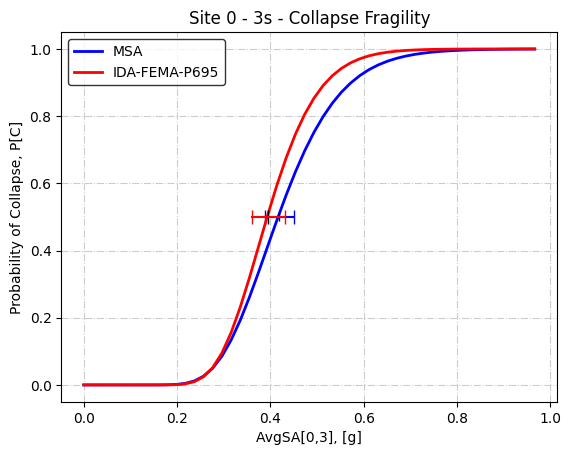

In [17]:
### MSA Uncertainty Estimation
im = AverageSpectralAcceleration(0, 10, n_periods=10)

n_tests = 30        # number of records per stripe
k_trials = 100        # number of fragility curves to create
site = 0
ns = 3
fc = fragility_curves[site][f"{ns}s_cbf_dc2_site{site}"]["msa"]

collapses = []
for im in fc["efc"][0, :]:
    p = lognorm.cdf(im, s=fc["dispersion"], scale=fc["median"])

    im_collapse_samples = np.random.binomial(n_tests, p, size=k_trials)
    collapses.append(im_collapse_samples)

ims = fc["efc"][0, :]
collapses = np.column_stack(collapses)

sim_fcs = []
for row in collapses:
    sim_fcs.append(fragility_from_msa(ims, row, n_tests, im))


fig, ax = plt.subplots()

im_max = lognorm.ppf(0.99, s=fc["dispersion"], scale=fc["median"])
imls = np.linspace(0, im_max*1.3, 50) # in g

# for sfc in sim_fcs:
#     ax.plot(imls, lognorm.cdf(imls, s=sfc.dispersion, scale=sfc.median),
#             color="b", alpha=0.05)


base_fc = lognorm.cdf(imls, s=fc["dispersion"], scale=fc["median"])
ax.plot(imls, base_fc, color="blue", lw=2, label="MSA")

mean_lnAvgSA = np.array([np.log(sfc.median) for sfc in sim_fcs])
sigma_lnAvgSA = np.array([sfc.dispersion for sfc in sim_fcs])

# B is a vector of ln(median) and ln(dispersion)
B_msa = np.column_stack([mean_lnAvgSA, np.log(sigma_lnAvgSA)])

# distribution of the mean of lnAvgSA
print("=== MSA RESULTS ===")
mu_mle, std_mle = norm.fit(mean_lnAvgSA)
print("MLE Estimates (normal):", np.exp(mu_mle), std_mle)
# this is not the right value --> I need to consider the Fisher transformation
# to be able to calculate the theoretical dispersion. As i have it this value
# will always be larger than the value calculated from the fit because the use
# of 30 records at multiple levels actually results in (~120) "tests" which 
# constrains the mean more. 
print("Normal Assumption:", np.exp(np.mean(mean_lnAvgSA)), fc["dispersion"] / np.sqrt(n_tests)) 
ci_90 = norm.interval(0.90, loc=mu_mle, scale=std_mle)
ci_95 = norm.interval(0.95, loc=mu_mle, scale=std_mle)
print("90% CI Width", ci_90[1] - ci_90[0])
print("95% CI Width", ci_95[1] - ci_95[0])

ax.plot(np.exp(mu_mle), 0.5, marker="|", mfc="k", mec="k")
ax.plot(np.exp(ci_95), [0.5, 0.5], color="b", marker="|", mec="b", markersize=10)
# ax.plot(np.exp(ci_90), [0.5, 0.5], color="k", ls="-", marker="|", mec="k")

# TODO:: distribution of the sigma of lnAvgSA
# this is a


### IDA Uncertainty Estimation
n_ida = 22      # number of records in the ida

fc_ida = fragility_curves[site][f"{ns}s_cbf_dc2_site{site}"]["ida-femap695"]

# sample the N_ida points randomly from this distribution (22-points) for k_trials
collapse_imls = np.random.lognormal(np.log(fc_ida["median"]), fc_ida["dispersion"], size=(k_trials, n_ida))

# fit the distribution of the median and dispersion
sim_ida_fcs = []
for row in collapse_imls:
    sim_ida_fcs.append(fragility_from_ida(row, im)) # todo add im properly

# for sfc in sim_ida_fcs:
#     ax.plot(imls, lognorm.cdf(imls, s=sfc.dispersion, scale=sfc.median),
#             color="r", alpha=0.05)

base_ida_fc = lognorm.cdf(imls, s=fc_ida["dispersion"], scale=fc_ida["median"])
ax.plot(imls, base_ida_fc, color="red", lw=2, label="IDA-FEMA-P695")

mean_lnAvgSA_ida = np.array([np.log(sfc.median) for sfc in sim_ida_fcs])
sigma_lnAvgSA_ida = np.array([sfc.dispersion for sfc in sim_ida_fcs])
# B is a vector of ln(median) and ln(dispersion)
B_ida = np.column_stack([mean_lnAvgSA_ida, np.log(sigma_lnAvgSA_ida)])

# calculate the confidence intervals
print("\n=== IDA (FEMA-P695) RESULTS ===")
mu_mle_ida, std_mle_ida = norm.fit(mean_lnAvgSA_ida)
print("MLE Estimates (normal):", np.exp(mu_mle_ida), std_mle_ida)
print("Normal Assumption:", np.exp(np.mean(mean_lnAvgSA_ida)), fc_ida["dispersion"] / np.sqrt(n_tests))

ci_90_ida = norm.interval(0.90, loc=mu_mle_ida, scale=std_mle_ida)
ci_95_ida = norm.interval(0.95, loc=mu_mle_ida, scale=std_mle_ida)
print("90% CI Width", ci_90_ida[1] - ci_90_ida[0])
print("95% CI Width", ci_95_ida[1] - ci_95_ida[0])

ax.plot(np.exp(mu_mle_ida), 0.5, marker="|", mfc="k", mec="k", markersize=10)
ax.plot(np.exp(ci_95_ida), [0.5, 0.5], color="r", marker="|", mec="r", markersize=10)
# ax.plot(np.exp(ci_90_ida), [0.5, 0.5], color="k", ls="-", marker="|", mec="k")


### Distribution of the Difference between MSA and IDA
# shuffle the list of median values for msa and ida
# take the difference
print("\n=== DELTA-THETA RESULTS ===")
delta_ln_theta = np.random.permutation(mean_lnAvgSA) - np.random.permutation(mean_lnAvgSA_ida)
# difference of two normal RVs is normal
mu_delta_theta, std_delta_theta = norm.fit(delta_ln_theta)
print("MLE Estimates:", np.exp(mu_mle_ida), std_mle_ida)

ci_90_delta_theta = norm.interval(0.90, loc=mu_delta_theta, scale=std_delta_theta)
ci_95_delta_theta = norm.interval(0.95, loc=mu_delta_theta, scale=std_delta_theta)
print("90% CI", f"{ci_90_delta_theta[1]:.3f}", f"{ci_90_delta_theta[0]:.3f}")
print("95% CI", f"{ci_95_delta_theta[1]:.3f}", f"{ci_95_delta_theta[0]:.3f}")

ax.grid(ls="-.", color="0.8")
ax.set_xlabel("AvgSA[0,3], [g]")
ax.set_ylabel("Probability of Collapse, P[C]")
ax.set_title(f"Site {site} - {ns}s - Collapse Fragility")
leg = ax.legend()
frame= leg.get_frame()
frame.set_edgecolor("k")

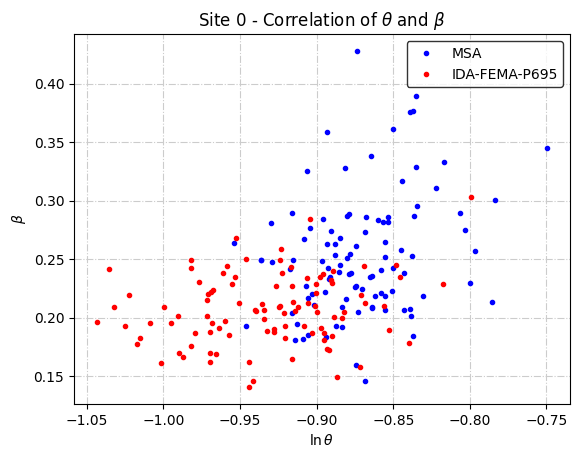

In [12]:
fig, ax = plt.subplots()
ax.plot(mean_lnAvgSA, sigma_lnAvgSA, marker=".", mfc="b", mec="b", ls="none", label="MSA")
ax.plot(mean_lnAvgSA_ida, sigma_lnAvgSA_ida, marker=".", mfc="r", mec="r", ls="none", label="IDA-FEMA-P695")

ax.set_ylabel(r"$\beta$")
ax.set_xlabel(r"$\ln{\theta}$")
ax.set_title(rf"Site {site} - Correlation of $\theta$ and $\beta$")
ax.grid(ls="-.", color="0.8")
leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")

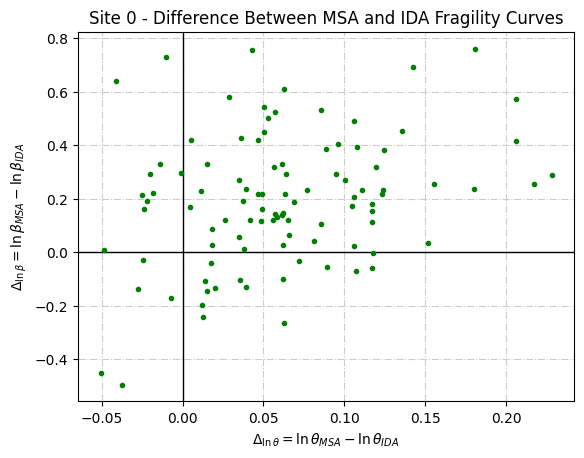

In [13]:
# Calculate the D vector (Difference vector) between IDA and MSA
D = B_msa - B_ida

fig, ax = plt.subplots()
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
ax.plot(D[:, 0], D[:, 1], marker=".", mfc="g", mec="g", ls="none")
ax.set_ylabel(r"$\Delta_{\ln{\beta}} = \ln{\beta_{MSA}} - \ln{\beta_{IDA}}$")
ax.set_xlabel(r"$\Delta_{\ln{\theta}} = \ln{\theta_{MSA}} - \ln{\theta_{IDA}}$")
ax.set_title(rf"Site {site} - Difference Between MSA and IDA Fragility Curves")
ax.grid(ls="-.", color="0.8")

In [14]:
# load fragility curve
fp = Path(r"C:\Users\clemettn\Documents\phd\data_processed\03_site_hazard\AvgSA_03_hazard_curves_60sites_4sig.pickle")

with open(fp, "rb") as file:
    hcs = pickle.load(file)


In [28]:
hc = hcs[site]["AvgSA"]["mean"]

combined_imls = sorted(np.concat([hc[:,0].flatten(), imls]))
fc_msa2 = lognorm.cdf(combined_imls, s=fc["dispersion"], scale=fc["median"])
fc_ida2 = lognorm.cdf(combined_imls, s=fc_ida["dispersion"], scale=fc_ida["median"])
hc_2 = np.interp(combined_imls, hc[:, 0], hc[:, 1])

mafc_msa = numerical_mafe(hc_2, fc_msa2)
mafc_ida = numerical_mafe(hc_2, fc_ida2)

print(f"{mafc_msa:.3e}", f"{mafc_ida:.3e}")
diff = (mafc_ida - mafc_msa) / mafc_msa * 100
print(f"{diff:.3f} [%]")

2.794e-06 3.141e-06
12.409 [%]


## Save Results

In [ ]:
sites = list(range(0, 60))
for site in sites:
    # TODO:: move fema p695 ida fragility curve

    # copy msa fragility curves to results
    
    
    ...